# ChemFF: Chemprop + Morgan Fingerprint Hybrid Model
## MoFPGNN — Morgan Fingerprint Augmented Graph Neural Network for LNP Transfection Efficiency Prediction

**Optimised for Google Colab + A100 GPU**
- Vectorised D-MPNN (scatter_add, no Python loops)
- AMP mixed precision (FP16 on A100)
- Large batch size (full dataset fits in GPU memory)

### Architecture
```
SMILES
  |
  +--- [D-MPNN Encoder] ---> embedding (300-dim)  --+
  |                                                  |-- concat --> [FFN Head] --> predicted mTP
  +--- [Morgan FP]      ---> fp vector (2048-dim) --+
  
  concat_dim = 300 + 2048 = 2348
  FFN: 2348 -> 1024 -> 512 -> 256 -> 1
```

In [ ]:
# ============================================================
# Cell 0: Google Colab Setup — Mount Drive & Install Deps
# ============================================================
import os, subprocess

# --- Mount Google Drive ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    # Set this to your project path on Google Drive:
    PROJECT_ROOT = '/content/drive/MyDrive/LANTERN'
    print(f"Running on Colab. Project root: {PROJECT_ROOT}")
except ImportError:
    IN_COLAB = False
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Running locally. Project root: {PROJECT_ROOT}")

# --- Install dependencies (Colab only) ---
if IN_COLAB:
    subprocess.run(['pip', 'install', '-q', 'rdkit-pypi', 'pyyaml', 'scipy', 'seaborn'], check=True)
    print("Dependencies installed.")

os.chdir(PROJECT_ROOT)

In [ ]:
# ============================================================
# Cell 1: Imports & GPU Config
# ============================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
import pickle
from copy import deepcopy
from scipy.stats import pearsonr, gaussian_kde, norm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Subset
from torch.amp import autocast, GradScaler

sys.path.insert(0, PROJECT_ROOT)

from chemff.model import ConcatFFN
from chemff.dataset import MoleculeDataset, collate_fn, load_dataset_from_config
from chemff.chemprop.featurizer import MolecularGraphFeaturizer, ATOM_FDIM, BOND_FDIM
from chemff.morgan.featurizer import MorganFeaturizer
from chemff.train import compute_metrics

# Plotting defaults
sns.set_theme(style='whitegrid', context='paper', font_scale=1.8)
plt.rcParams['figure.dpi'] = 150

# Results directory
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'chemff')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- GPU Detection & Config ----
if torch.cuda.is_available():
    DEVICE = 'cuda'
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
    # Enable TF32 for A100 (free ~3x speedup on matmuls)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
    print("Device: Apple MPS")
else:
    DEVICE = 'cpu'
    print("Device: CPU")

USE_AMP = DEVICE == 'cuda'  # AMP only on CUDA (A100)
print(f"Device: {DEVICE}, AMP: {USE_AMP}")

# ---- A100-optimised hyperparameters ----
# Larger batch = better GPU utilisation (A100 has 40-80GB)
BATCH_SIZE = 256 if DEVICE == 'cuda' else 100
NUM_WORKERS = 4 if DEVICE == 'cuda' else 0
EPOCHS = 150 if DEVICE == 'cuda' else 100
LR = 3e-4 if DEVICE == 'cuda' else 2e-4

print(f"Batch size: {BATCH_SIZE}, Workers: {NUM_WORKERS}, Epochs: {EPOCHS}, LR: {LR}")

---
## Part 1: Data Exploration & Morgan Fingerprint Analysis

In [ ]:
# ============================================================
# Cell 2: Load Data, Config, Morgan FPs
# ============================================================
with open('chemff/config.yaml') as f:
    cfg = yaml.safe_load(f)

# Override config with A100-optimised settings
cfg['device'] = DEVICE
cfg['batch_size'] = BATCH_SIZE
cfg['num_workers'] = NUM_WORKERS
cfg['epochs'] = EPOCHS
cfg['lr'] = LR
cfg['use_amp'] = USE_AMP

df = pd.read_csv(cfg['data_path'])
smiles_list = df['SMILES'].tolist()
labels = df['Target'].tolist()

print(f"Dataset: {len(smiles_list)} molecules")
print(f"Target range: [{min(labels):.3f}, {max(labels):.3f}]")
print(f"Target mean: {np.mean(labels):.3f}, std: {np.std(labels):.3f}")

# Generate Morgan FPs if needed
fp_path = cfg['morgan']['fp_path']
if not os.path.exists(fp_path):
    print(f"Generating Morgan fingerprints (2048-bit)...")
    featurizer = MorganFeaturizer(
        radius=cfg['morgan']['radius'], n_bits=cfg['morgan']['n_bits'],
        use_counts=cfg['morgan']['use_counts'], use_chirality=cfg['morgan']['use_chirality'],
    )
    featurizer.save(smiles_list, fp_path)

morgan_fp_dict = MorganFeaturizer.load(fp_path)
fp_matrix = np.array([morgan_fp_dict[s] for s in smiles_list])  # (1100, 2048)

print(f"\nMorgan FP matrix: {fp_matrix.shape}")
print(f"Sparsity: {(fp_matrix == 0).mean():.1%} zeros")
print(f"\nConfig: Chemprop {cfg['chemprop']['output_dim']}-dim + Morgan {cfg['morgan']['n_bits']}-dim = {cfg['chemprop']['output_dim'] + cfg['morgan']['n_bits']}-dim concat")
print(f"FFN head: {cfg['ffn']['hidden_layers']} -> {cfg['ffn']['output_dim']}")
df.head()

### Visualization 1 — mTP Target Distribution

### Visualization 2 — Morgan Fingerprint Sparsity Heatmap

Morgan FP matrix shape: (1100, 2048)
Sparsity: 97.4% zeros
Max count in any bit: 47


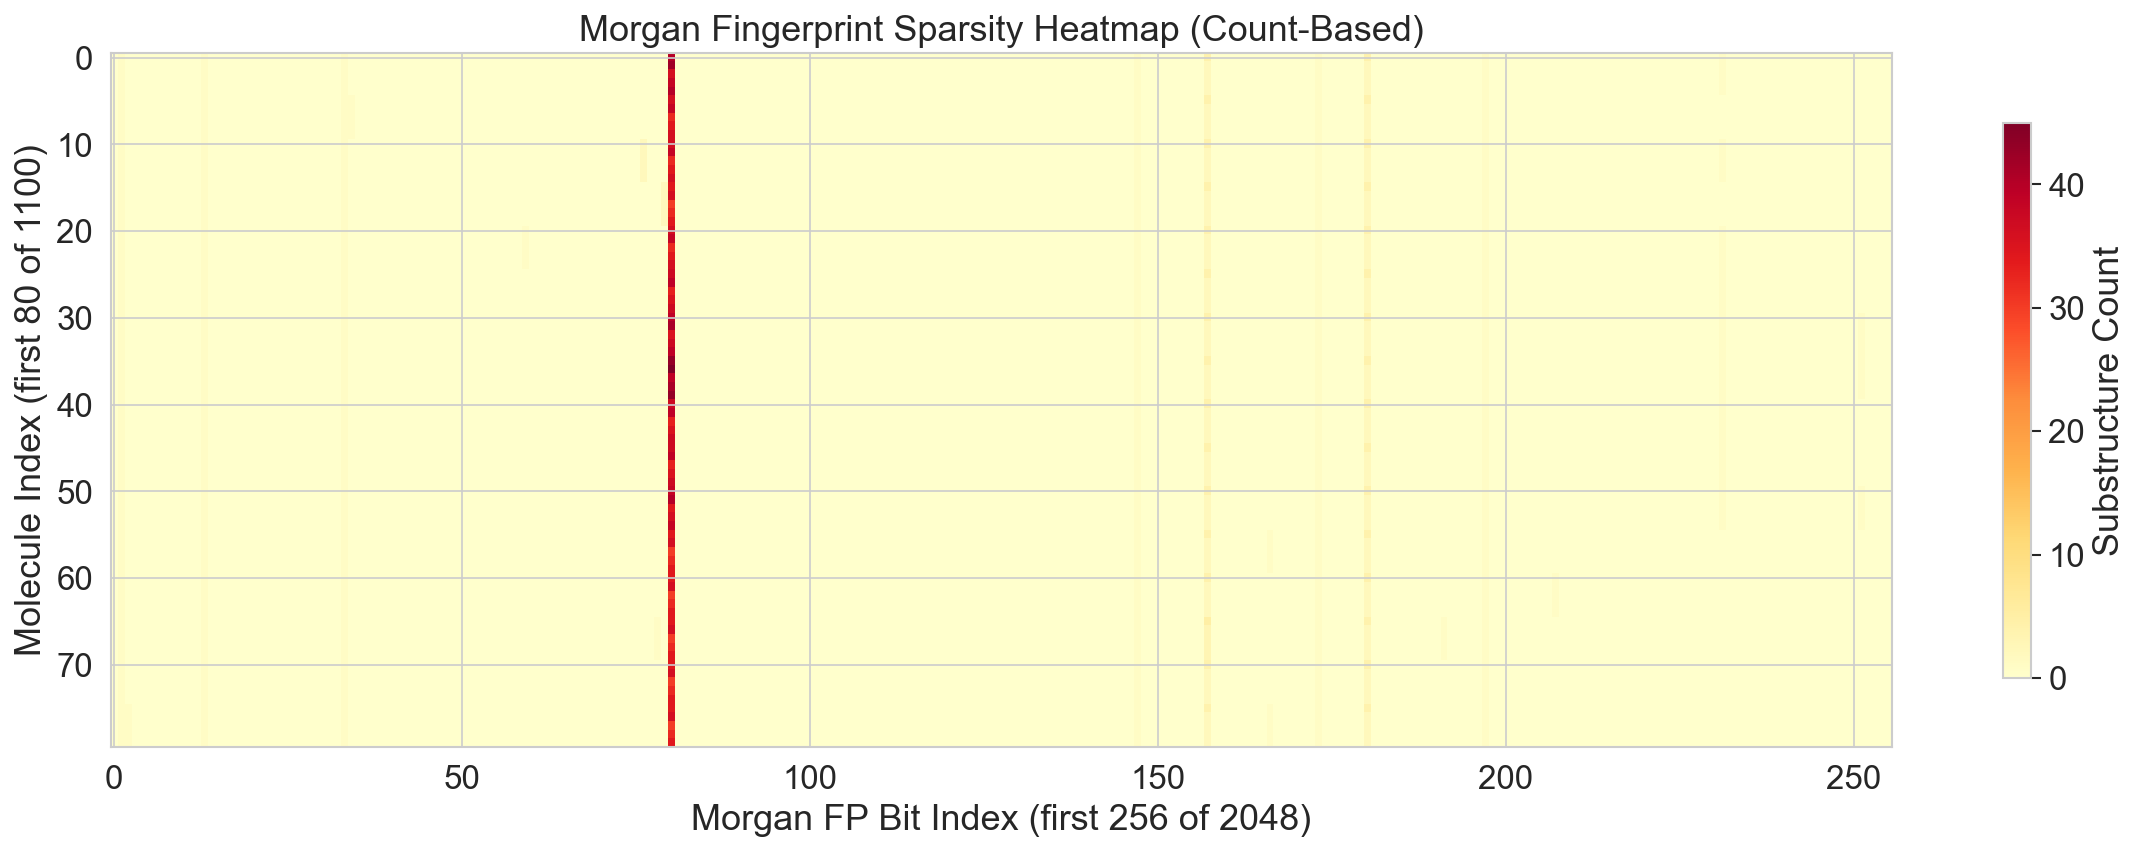

In [4]:
# ============================================================
# Viz 2: Morgan FP Sparsity Heatmap
# ============================================================
# Load pre-computed Morgan fingerprints
morgan_fp_dict = MorganFeaturizer.load(cfg['morgan']['fp_path'])
fp_matrix = np.array([morgan_fp_dict[s] for s in smiles_list])  # (1100, 2048)
print(f"Morgan FP matrix shape: {fp_matrix.shape}")
print(f"Sparsity: {(fp_matrix == 0).mean():.1%} zeros")
print(f"Max count in any bit: {fp_matrix.max():.0f}")

# Show a subset: first 80 molecules x first 256 bits
fig, ax = plt.subplots(figsize=(16, 6))
subset = fp_matrix[:80, :256]
im = ax.imshow(subset, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Morgan FP Bit Index (first 256 of 2048)')
ax.set_ylabel('Molecule Index (first 80 of 1100)')
ax.set_title('Morgan Fingerprint Sparsity Heatmap (Count-Based)')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Substructure Count')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz02_morgan_sparsity_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 3 — Morgan FP Bit Frequency & Activation Analysis

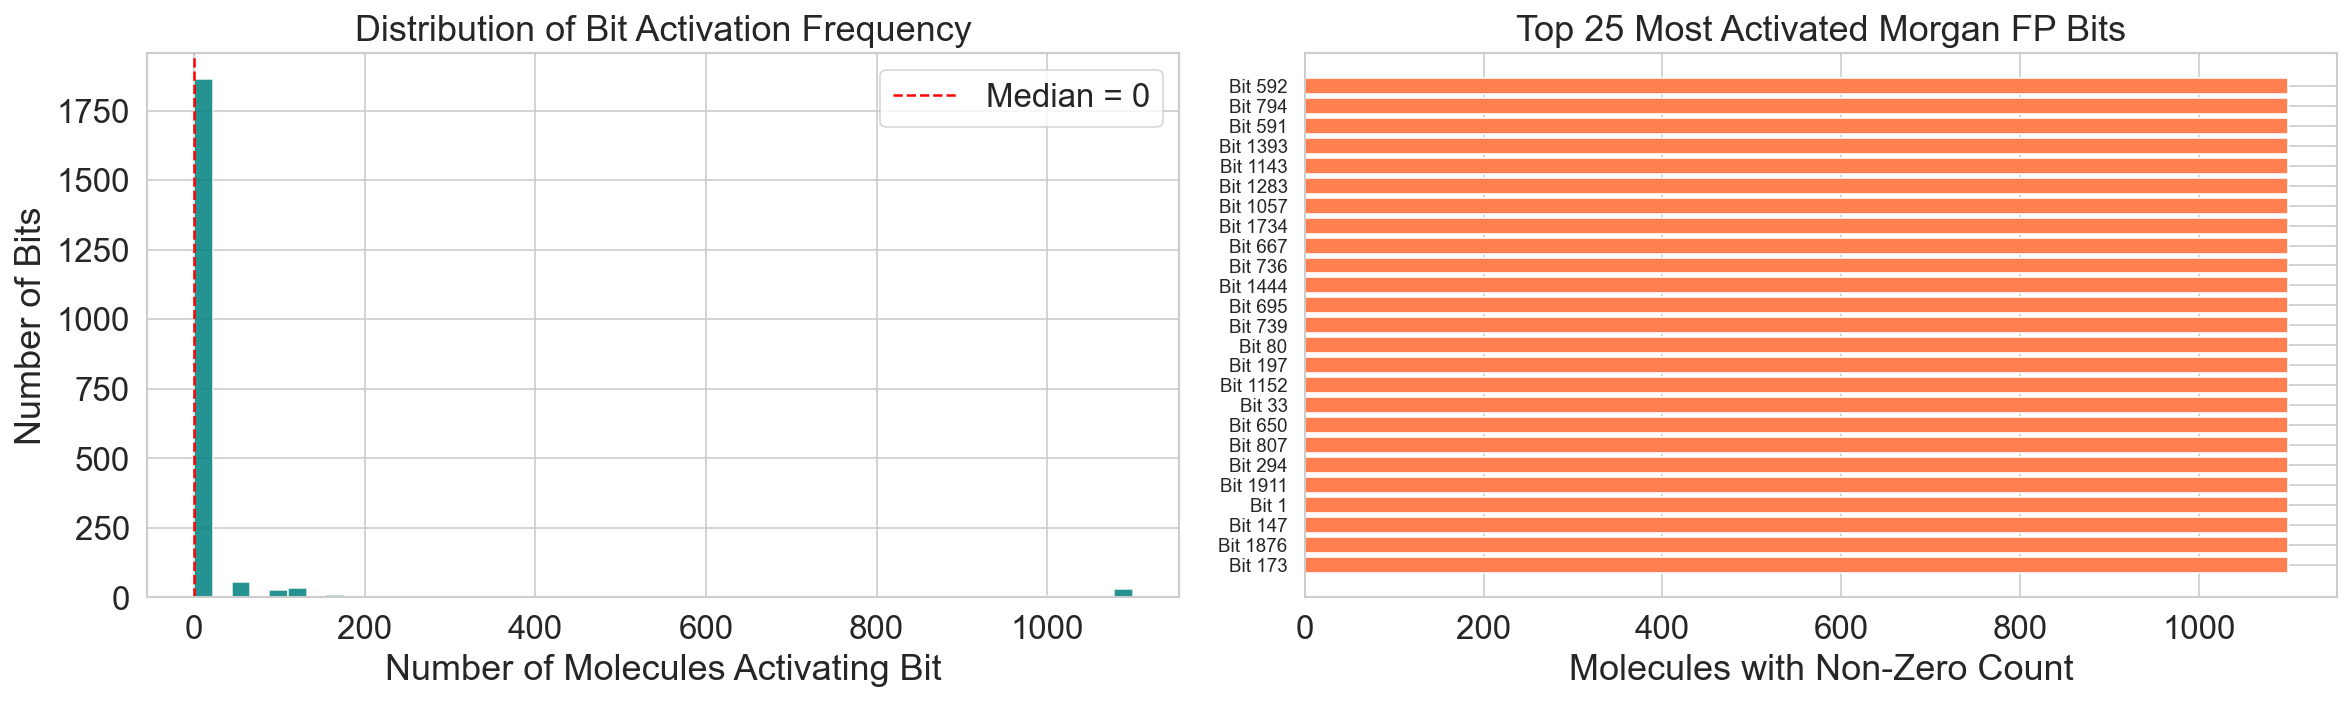

Active bits: 185/2048 (9.0%)
Dead bits (never activated): 1863/2048 (91.0%)


In [5]:
# ============================================================
# Viz 3: Bit Frequency Histogram + Top/Bottom Activated Bits
# ============================================================
bit_activation_freq = (fp_matrix > 0).sum(axis=0)  # how many molecules activate each bit
bit_mean_count = fp_matrix.mean(axis=0)             # average count per bit

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Histogram of bit activation frequencies
axes[0].hist(bit_activation_freq, bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of Molecules Activating Bit')
axes[0].set_ylabel('Number of Bits')
axes[0].set_title('Distribution of Bit Activation Frequency')
axes[0].axvline(np.median(bit_activation_freq), color='red', linestyle='--',
                label=f'Median = {np.median(bit_activation_freq):.0f}')
axes[0].legend()

# (b) Top 25 most activated bits
top_k = 25
top_indices = np.argsort(bit_activation_freq)[-top_k:][::-1]
axes[1].barh(range(top_k), bit_activation_freq[top_indices], color='coral', edgecolor='white')
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([f'Bit {i}' for i in top_indices], fontsize=9)
axes[1].set_xlabel('Molecules with Non-Zero Count')
axes[1].set_title(f'Top {top_k} Most Activated Morgan FP Bits')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz03_bit_frequency.png'), dpi=300, bbox_inches='tight')
plt.show()

n_active = (bit_activation_freq > 0).sum()
n_dead = (bit_activation_freq == 0).sum()
print(f"Active bits: {n_active}/2048 ({n_active/2048:.1%})")
print(f"Dead bits (never activated): {n_dead}/2048 ({n_dead/2048:.1%})")

### Visualization 4 — t-SNE of Morgan Fingerprint Space

Computing t-SNE embedding (this may take a moment)...


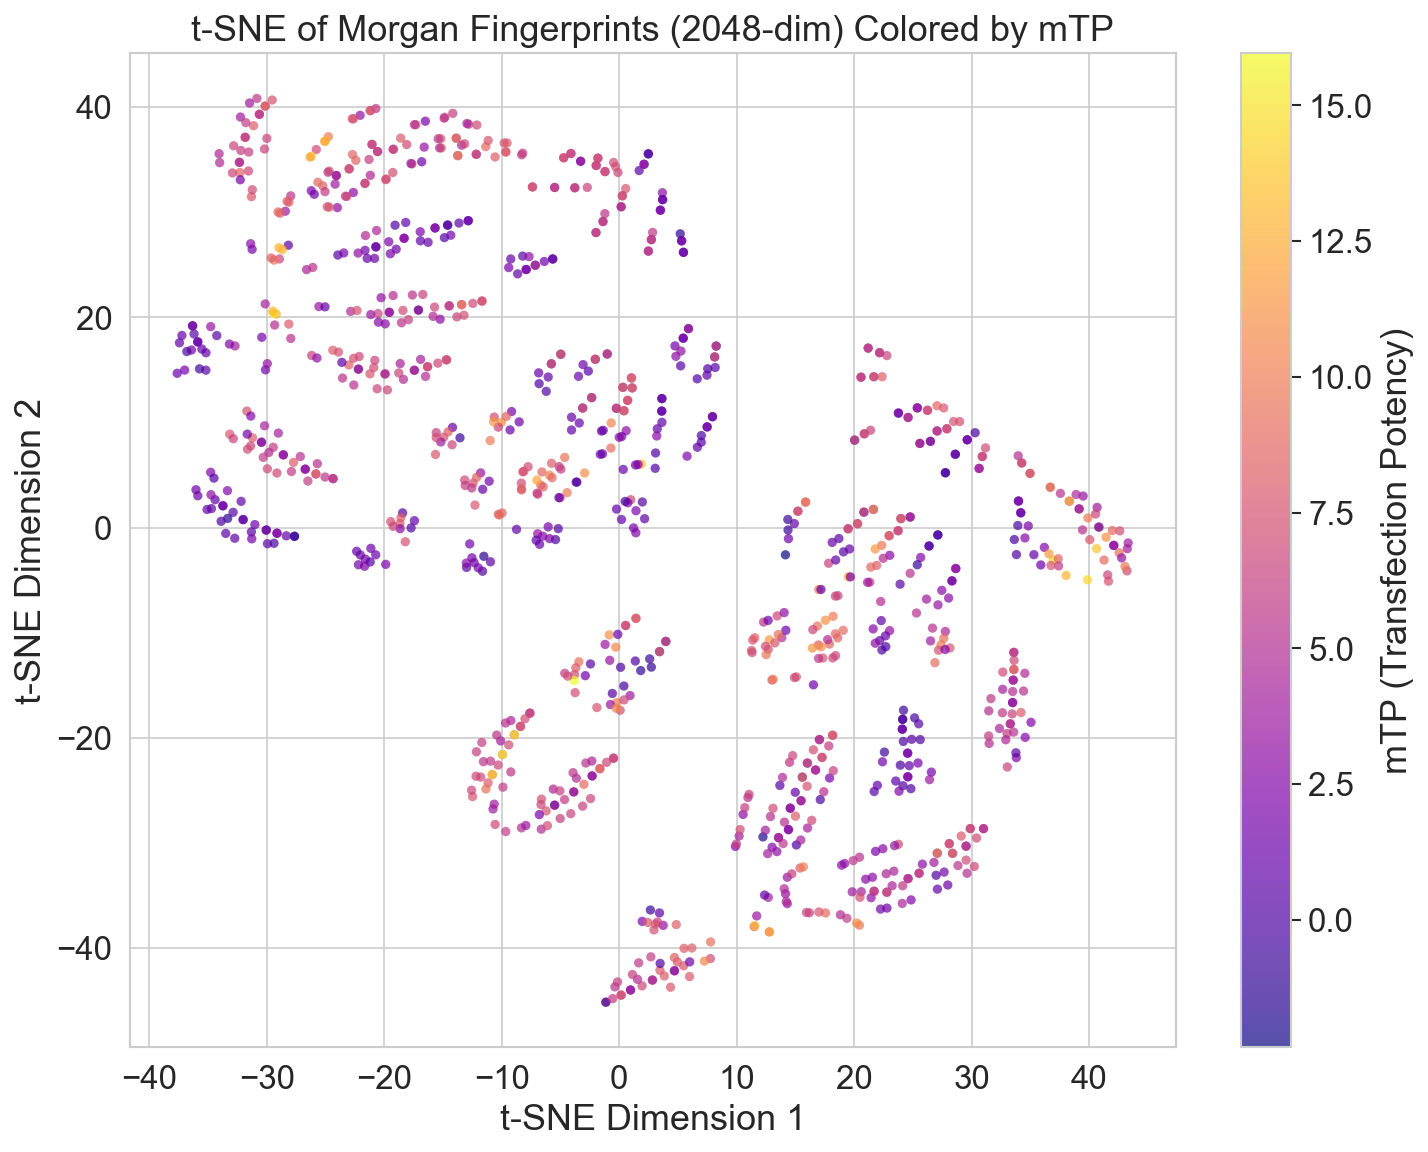

In [6]:
# ============================================================
# Viz 4: t-SNE of Morgan FP Space Colored by mTP
# ============================================================
print("Computing t-SNE embedding (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
fp_2d = tsne.fit_transform(fp_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(fp_2d[:, 0], fp_2d[:, 1], c=labels, cmap='plasma',
                     s=20, alpha=0.7, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('mTP (Transfection Potency)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('t-SNE of Morgan Fingerprints (2048-dim) Colored by mTP')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz04_tsne_morgan.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## Part 2: Model Training

### Visualization 5 — Architecture Diagram

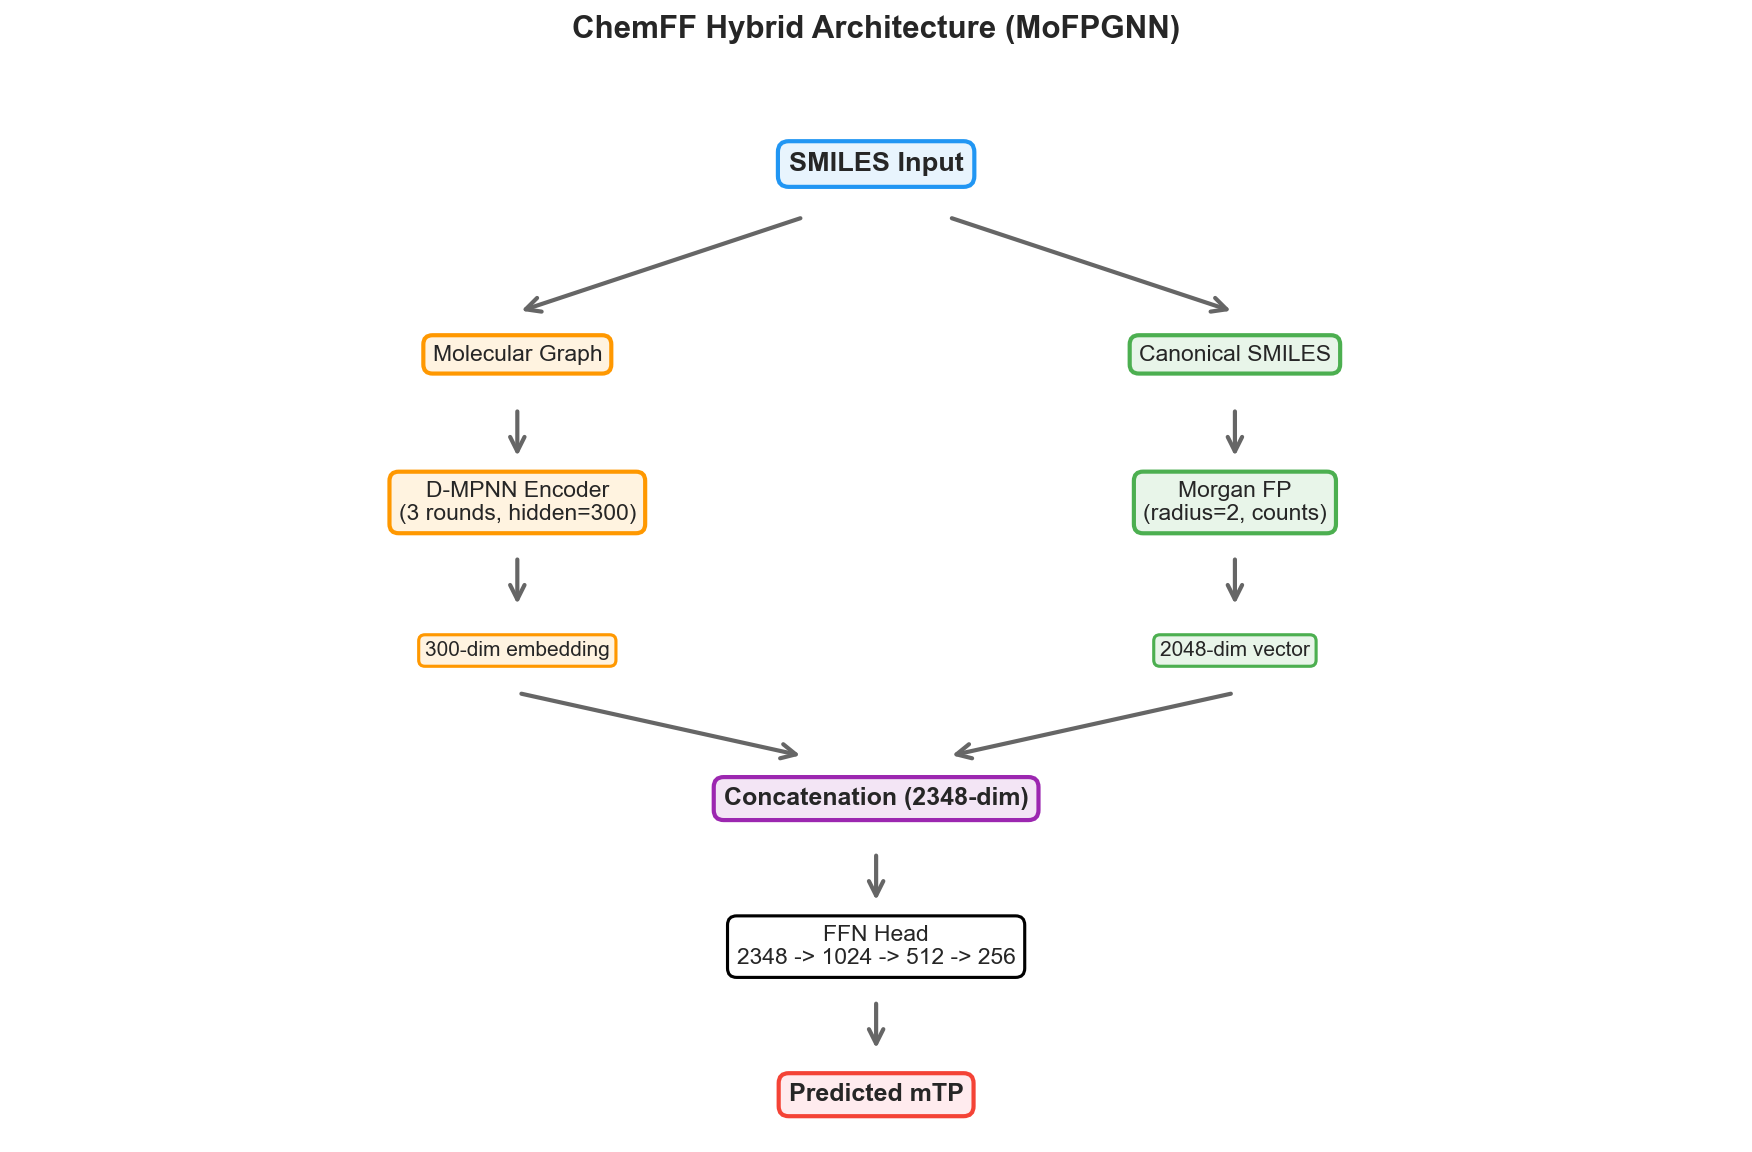

In [7]:
# ============================================================
# Viz 5: Architecture Diagram
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')

box_style = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', linewidth=1.5)
input_style = dict(boxstyle='round,pad=0.4', facecolor='#E8F4FD', edgecolor='#2196F3', linewidth=2)
branch_a = dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', edgecolor='#FF9800', linewidth=2)
branch_b = dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#4CAF50', linewidth=2)
concat_style = dict(boxstyle='round,pad=0.4', facecolor='#F3E5F5', edgecolor='#9C27B0', linewidth=2)
output_style = dict(boxstyle='round,pad=0.4', facecolor='#FFEBEE', edgecolor='#F44336', linewidth=2)

# Input
ax.text(6, 9.2, 'SMILES Input', fontsize=13, fontweight='bold', ha='center', va='center', bbox=input_style)

# Branch arrows
ax.annotate('', xy=(3.5, 7.8), xytext=(5.5, 8.7), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.annotate('', xy=(8.5, 7.8), xytext=(6.5, 8.7), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))

# D-MPNN branch
ax.text(3.5, 7.4, 'Molecular Graph', fontsize=11, ha='center', va='center', bbox=branch_a)
ax.annotate('', xy=(3.5, 6.4), xytext=(3.5, 6.9), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(3.5, 6.0, 'D-MPNN Encoder\n(3 rounds, hidden=300)', fontsize=11, ha='center', va='center', bbox=branch_a)
ax.annotate('', xy=(3.5, 5.0), xytext=(3.5, 5.5), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(3.5, 4.6, '300-dim embedding', fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='#FF9800', linewidth=1.5))

# Morgan branch
ax.text(8.5, 7.4, 'Canonical SMILES', fontsize=11, ha='center', va='center', bbox=branch_b)
ax.annotate('', xy=(8.5, 6.4), xytext=(8.5, 6.9), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(8.5, 6.0, 'Morgan FP\n(radius=2, counts)', fontsize=11, ha='center', va='center', bbox=branch_b)
ax.annotate('', xy=(8.5, 5.0), xytext=(8.5, 5.5), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(8.5, 4.6, '2048-dim vector', fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#4CAF50', linewidth=1.5))

# Concatenation
ax.annotate('', xy=(5.5, 3.6), xytext=(3.5, 4.2), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.annotate('', xy=(6.5, 3.6), xytext=(8.5, 4.2), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(6, 3.2, 'Concatenation (2348-dim)', fontsize=12, fontweight='bold', ha='center', va='center', bbox=concat_style)

# FFN head
ax.annotate('', xy=(6, 2.2), xytext=(6, 2.7), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(6, 1.8, 'FFN Head\n2348 -> 1024 -> 512 -> 256', fontsize=11, ha='center', va='center', bbox=box_style)

# Output
ax.annotate('', xy=(6, 0.8), xytext=(6, 1.3), arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(6, 0.4, 'Predicted mTP', fontsize=12, fontweight='bold', ha='center', va='center', bbox=output_style)

plt.title('ChemFF Hybrid Architecture (MoFPGNN)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz05_architecture.png'), dpi=300, bbox_inches='tight')
plt.show()

### Training the ChemFF Model

In [ ]:
# ============================================================
# Cell 6: Build DataLoaders (GPU-optimised)
# ============================================================
from chemff.train import prepare_dataloaders

loaders, (train_idx, val_idx, test_idx) = prepare_dataloaders(cfg, smiles_list, labels)
print(f"Split sizes: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")
print(f"Batch size: {cfg['batch_size']}, Workers: {cfg.get('num_workers', 0)}")
print(f"pin_memory: {DEVICE == 'cuda'}")

# Build model
model = ConcatFFN(
    chemprop_hidden_size=cfg['chemprop']['hidden_size'],
    chemprop_depth=cfg['chemprop']['depth'],
    chemprop_dropout=cfg['chemprop']['dropout'],
    morgan_n_bits=cfg['morgan']['n_bits'],
    ffn_hidden_layers=cfg['ffn']['hidden_layers'],
    ffn_dropout=cfg['ffn']['dropout'],
    output_dim=cfg['ffn']['output_dim'],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")
print(f"  D-MPNN params: {sum(p.numel() for p in model.chemprop_encoder.parameters()):,}")
print(f"  FFN head params: {sum(p.numel() for p in model.ffn_head.parameters()):,}")

if DEVICE == 'cuda':
    print(f"\nGPU memory allocated: {torch.cuda.memory_allocated()/1e6:.1f} MB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e6:.1f} MB")

In [ ]:
# ============================================================
# Cell 7: Training Loop (AMP + A100 Optimised)
# ============================================================
import time
from chemff.train import train_one_epoch, evaluate

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# AMP scaler (only for CUDA)
scaler = GradScaler('cuda') if USE_AMP else None
if USE_AMP:
    print("AMP mixed precision ENABLED (FP16 on A100)")

best_val_loss = float('inf')
best_model = None
train_losses, val_losses = [], []

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, loaders['train'], criterion, optimizer, DEVICE, scaler, USE_AMP
    )
    val_loss, _, _ = evaluate(model, loaders['val'], criterion, DEVICE, USE_AMP)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        eps = (epoch + 1) / elapsed
        eta = (EPOCHS - epoch - 1) / eps
        print(f"Epoch {epoch+1:>3}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"{eps:.1f} ep/s | ETA: {eta:.0f}s")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time:.1f}s ({total_time/EPOCHS:.2f}s/epoch)")
print(f"Best Val Loss: {best_val_loss:.4f}")

# Save checkpoint
ckpt_dir = cfg.get('checkpoint_dir', 'checkpoints/chemff')
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, 'chemff_model.pth')
torch.save(best_model.state_dict(), ckpt_path)
print(f"Checkpoint saved -> {ckpt_path}")

if DEVICE == 'cuda':
    print(f"Peak GPU memory: {torch.cuda.max_memory_allocated()/1e6:.1f} MB")

In [ ]:
# ============================================================
# Cell 8: Evaluate on all splits
# ============================================================
model = best_model
model.eval()

split_results = {}
for split_name in ['train', 'val', 'test']:
    loss, preds, lbls = evaluate(model, loaders[split_name], criterion, DEVICE, USE_AMP)
    metrics = compute_metrics(preds, lbls)
    split_results[split_name] = {'preds': preds, 'labels': lbls, 'metrics': metrics}
    print(f"\n=== {split_name.upper()} Metrics ===")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

---
## Part 3: Post-Training Visualizations

### Visualization 6 — Training Loss Curves

In [ ]:
# ============================================================
# Viz 6: Training Loss Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Full loss curves
axes[0].plot(train_losses, label='Train', color='#2196F3', linewidth=2)
axes[0].plot(val_losses, label='Validation', color='#FF9800', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Log scale for detail
axes[1].plot(train_losses, label='Train', color='#2196F3', linewidth=2)
axes[1].plot(val_losses, label='Validation', color='#FF9800', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Loss Curves (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz06_loss_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 7 — Prediction vs True Scatter Plots

In [ ]:
# ============================================================
# Viz 7: Prediction vs True Scatter Plots (train/val/test)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
split_colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for ax, split_name in zip(axes, ['train', 'val', 'test']):
    preds = split_results[split_name]['preds']
    lbls = split_results[split_name]['labels']
    metrics = split_results[split_name]['metrics']

    # Density coloring
    xy = np.vstack([lbls, preds])
    z = gaussian_kde(xy)(xy)

    ax.scatter(lbls, preds, c=z, cmap='viridis', s=30, alpha=0.7, edgecolors='none')

    # y = x line
    lims = [min(lbls.min(), preds.min()) - 0.5, max(lbls.max(), preds.max()) + 0.5]
    ax.plot(lims, lims, 'r--', linewidth=2, alpha=0.7, label='y = x')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel('True mTP')
    ax.set_ylabel('Predicted mTP')
    ax.set_title(f'{split_name.upper()}\n$R^2$={metrics["R2"]:.3f}  RMSE={metrics["RMSE"]:.3f}  r={metrics["Pearson_r"]:.3f}')
    ax.legend(fontsize=10)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz07_prediction_vs_true.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 8 — Confusion Matrix Heatmaps (Percentile-Based)

In [ ]:
# ============================================================
# Viz 8: Confusion Matrix Heatmaps (Percentile-Based)
# ============================================================
def convert_to_class(labels, preds, num_classes):
    """Convert continuous values to percentile-based classes."""
    label_p = [np.percentile(labels, 100 / num_classes * (i + 1)) for i in range(num_classes - 1)]
    pred_p = [np.percentile(preds, 100 / num_classes * (i + 1)) for i in range(num_classes - 1)]
    label_cls = [sum([1 for x in label_p if x > label]) for label in labels]
    pred_cls = [sum([1 for x in pred_p if x > pred]) for pred in preds]
    return label_cls, pred_cls

num_classes = 6
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, split_name in zip(axes, ['train', 'val', 'test']):
    preds = split_results[split_name]['preds']
    lbls = split_results[split_name]['labels']

    label_cls, pred_cls = convert_to_class(lbls, preds, num_classes)
    cm = confusion_matrix(label_cls, pred_cls, normalize='true')
    class_labels = [f'{i}' for i in range(num_classes)]

    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=0.75,
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_xlabel('Predicted Percentile')
    ax.set_ylabel('Actual Percentile')
    ax.set_title(f'{split_name.upper()} Confusion Matrix')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz08_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 9 — Residual Distribution

In [ ]:
# ============================================================
# Viz 9: Residual Distribution (Histogram + KDE)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for ax, split_name in zip(axes, ['train', 'val', 'test']):
    residuals = split_results[split_name]['preds'] - split_results[split_name]['labels']
    
    ax.hist(residuals, bins=30, color=colors[split_name], edgecolor='white', 
            alpha=0.7, density=True, label='Histogram')
    
    # Gaussian fit overlay
    mu, std = norm.fit(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax.plot(x, norm.pdf(x, mu, std), 'k-', linewidth=2, label=f'N({mu:.2f}, {std:.2f})')
    
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Residual (Pred - True)')
    ax.set_ylabel('Density')
    ax.set_title(f'{split_name.upper()} Residuals\nmean={mu:.3f}, std={std:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz09_residual_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 10 — Cumulative Error Distribution (CDF)

In [ ]:
# ============================================================
# Viz 10: Cumulative Error Distribution (CDF of Absolute Errors)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for split_name in ['train', 'val', 'test']:
    abs_errors = np.abs(split_results[split_name]['preds'] - split_results[split_name]['labels'])
    sorted_errors = np.sort(abs_errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    ax.plot(sorted_errors, cdf, label=split_name.upper(), color=colors[split_name], linewidth=2)

# Reference lines
for threshold in [0.5, 1.0, 1.5]:
    ax.axvline(threshold, color='gray', linestyle=':', alpha=0.5)
    ax.text(threshold + 0.02, 0.05, f'{threshold}', fontsize=9, color='gray')

ax.set_xlabel('Absolute Error |Pred - True|')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('Cumulative Distribution of Absolute Prediction Errors')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz10_cdf_errors.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print fraction within thresholds
for split_name in ['train', 'val', 'test']:
    abs_errors = np.abs(split_results[split_name]['preds'] - split_results[split_name]['labels'])
    for t in [0.5, 1.0, 1.5]:
        frac = (abs_errors <= t).mean()
        print(f"  {split_name.upper()}: {frac:.1%} of predictions within +/-{t}")

### Visualization 11 — Top-k% Ranking Accuracy

In [ ]:
# ============================================================
# Viz 11: Top-k% Ranking Accuracy
# ============================================================
def top_k_accuracy(preds, labels, k_pct):
    """Fraction of true top-k% compounds recovered in predicted top-k%."""
    n = len(labels)
    top_n = max(1, int(n * k_pct / 100))
    true_top = set(np.argsort(labels)[-top_n:])
    pred_top = set(np.argsort(preds)[-top_n:])
    return len(true_top & pred_top) / top_n

k_values = [5, 10, 15, 20, 25, 50]
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(k_values))
width = 0.25
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for i, split_name in enumerate(['train', 'val', 'test']):
    preds = split_results[split_name]['preds']
    lbls = split_results[split_name]['labels']
    accuracies = [top_k_accuracy(preds, lbls, k) for k in k_values]
    bars = ax.bar(x + i * width, accuracies, width, label=split_name.upper(),
                  color=colors[split_name], edgecolor='white')
    # Value labels
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.0%}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Top-k%')
ax.set_ylabel('Recovery Rate')
ax.set_title('Top-k% Ranking Accuracy\n(Fraction of true top-k% recovered in predicted top-k%)')
ax.set_xticks(x + width)
ax.set_xticklabels([f'{k}%' for k in k_values])
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz11_topk_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 12 — Metrics Comparison Bar Chart

In [ ]:
# ============================================================
# Viz 12: Metrics Comparison Bar Chart (Grouped by Split)
# ============================================================
metric_names = ['R2', 'RMSE', 'MAE', 'Pearson_r']
display_names = ['$R^2$', 'RMSE', 'MAE', 'Pearson $r$']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for ax, metric, display in zip(axes, metric_names, display_names):
    vals = [split_results[s]['metrics'][metric] for s in ['train', 'val', 'test']]
    bars = ax.bar(['Train', 'Val', 'Test'], vals,
                  color=[colors['train'], colors['val'], colors['test']],
                  edgecolor='white', width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(display, fontsize=14)
    ax.set_ylabel(display)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ChemFF Model Performance Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz12_metrics_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

### Visualization 13 — Dimension Breakdown & Concatenation Diagram

In [ ]:
# ============================================================
# Viz 13: Dimension Breakdown — Stacked Bar + Pie Chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Stacked bar showing concatenation
chemprop_dim = cfg['chemprop']['output_dim']  # 300
morgan_dim = cfg['morgan']['n_bits']          # 2048
concat_dim = chemprop_dim + morgan_dim        # 2348
ffn_layers = cfg['ffn']['hidden_layers']      # [1024, 512, 256]

layer_dims = [concat_dim] + ffn_layers + [1]
layer_names = ['Input\n(concat)', 'Hidden 1', 'Hidden 2', 'Hidden 3', 'Output']

# Stacked bar for the input layer
axes[0].barh(0, chemprop_dim, color='#FF9800', edgecolor='white', height=0.5, label=f'D-MPNN ({chemprop_dim})')
axes[0].barh(0, morgan_dim, left=chemprop_dim, color='#4CAF50', edgecolor='white', height=0.5, label=f'Morgan FP ({morgan_dim})')

# Other layers
for i, (dim, name) in enumerate(zip(layer_dims[1:], layer_names[1:])):
    axes[0].barh(-(i+1), dim, color='#9C27B0' if i < 3 else '#F44336', edgecolor='white', height=0.5, alpha=0.7)
    axes[0].text(dim + 20, -(i+1), f'{dim}', va='center', fontsize=11)

axes[0].set_yticks(range(0, -len(layer_names), -1))
axes[0].set_yticklabels(layer_names)
axes[0].set_xlabel('Dimension')
axes[0].set_title('Layer-by-Layer Dimension Flow')
axes[0].legend(loc='upper right')

# (b) Pie chart: proportion of Morgan vs D-MPNN in concat
sizes = [chemprop_dim, morgan_dim]
labels_pie = [f'D-MPNN\n{chemprop_dim} dims\n({chemprop_dim/concat_dim:.1%})',
              f'Morgan FP\n{morgan_dim} dims\n({morgan_dim/concat_dim:.1%})']
colors_pie = ['#FF9800', '#4CAF50']
explode = (0.05, 0)

axes[1].pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
            autopct='', startangle=90, textprops={'fontsize': 12})
axes[1].set_title(f'Concatenated Vector Composition\n(Total: {concat_dim} dims)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz13_dimension_breakdown.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDimension Summary:")
print(f"  D-MPNN output:    {chemprop_dim:>5} dims  ({chemprop_dim/concat_dim:>5.1%} of concat)")
print(f"  Morgan FP:        {morgan_dim:>5} dims  ({morgan_dim/concat_dim:>5.1%} of concat)")
print(f"  Concatenated:     {concat_dim:>5} dims")
print(f"  FFN layers:       {concat_dim} -> {' -> '.join(map(str, ffn_layers))} -> 1")

### Visualization 14 — Prediction Error vs True mTP (Error Analysis)

In [ ]:
# ============================================================
# Viz 14: Absolute Error vs True mTP (where does the model struggle?)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for split_name in ['train', 'val', 'test']:
    preds = split_results[split_name]['preds']
    lbls = split_results[split_name]['labels']
    abs_err = np.abs(preds - lbls)
    ax.scatter(lbls, abs_err, c=colors[split_name], s=15, alpha=0.5, label=split_name.upper())

ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Error = 1.0')
ax.set_xlabel('True mTP')
ax.set_ylabel('Absolute Error')
ax.set_title('Prediction Error vs True Transfection Potency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'viz14_error_vs_true.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## Summary

### GPU Optimizations Applied
| Optimization | Impact |
|---|---|
| **Vectorised D-MPNN** (scatter_add) | ~50-100x faster message passing (no Python loops) |
| **AMP mixed precision** (FP16) | ~2x throughput on A100 Tensor Cores |
| **TF32 mode** | ~3x faster matmuls on A100 |
| **Larger batch size** (256) | Better GPU utilisation |
| **pin_memory + num_workers** | Faster CPU-to-GPU data transfer |
| **Gradient clipping** | Training stability |
| **cudnn.benchmark** | Auto-tuned convolution kernels |

### Model Architecture
| Component | Dimension | Description |
|---|---|---|
| Morgan FP | **2,048** | Count-based circular fingerprint (radius=2, chirality-aware) |
| D-MPNN Embedding | **300** | Directed Message Passing Neural Network (3 rounds) |
| Concatenation | **2,348** | Late fusion: `[D-MPNN || Morgan FP]` |
| FFN Head | 2348 -> 1024 -> 512 -> 256 -> 1 | ReLU + Dropout(0.1) |

### Visualizations Generated (14 total)
1. mTP target distribution
2. Morgan FP sparsity heatmap
3. Bit frequency & activation analysis
4. t-SNE of Morgan FP space
5. Architecture diagram
6. Training loss curves
7. Prediction vs true scatter plots
8. Confusion matrix heatmaps
9. Residual distributions
10. Cumulative error distribution (CDF)
11. Top-k% ranking accuracy
12. Metrics comparison bar chart
13. Dimension breakdown & concatenation
14. Error analysis vs true mTP